# Week 3 - Day 5
## Supervised Learning Mini-Project

**Dataset:** IBM Telco Customer Churn  
**Objective:** Predict whether a telecom customer will churn.  

Because the target `Churn` has two possible classes (`Yes` or `No`), this is a **binary classification** problem. The notebook follows a complete workflow from raw-data inspection and EDA to preprocessing, model comparison, interpretation, and final model selection.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)

## 2. Load and Inspect the Raw Data

First, we load the Telco Customer Churn dataset using Pandas and display the first five rows to get an initial view of the features and values.

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
print("Missing values before cleaning:")
print(df.isna().sum())

print("\nDuplicated rows:", df.duplicated().sum())

print("\nRaw Churn distribution:")
print(df["Churn"].value_counts())
print("\nChurn percentages:")
print((df["Churn"].value_counts(normalize=True) * 100).round(2))

Missing values before cleaning:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicated rows: 0

Raw Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentages:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


### Raw-data observation
`TotalCharges` appears as an `object` column even though it should be numeric. The standard missing-value check does not reveal the problem yet because some missing entries are stored as blank strings rather than `NaN`.

## 3. Data Cleaning

In [6]:
blank_total_charges = df["TotalCharges"].astype(str).str.strip().eq("").sum()
print("Blank TotalCharges values:", blank_total_charges)

Blank TotalCharges values: 11


The blank `TotalCharges` values are converted to missing values with `pd.to_numeric(..., errors="coerce")`. Only 11 rows are affected out of more than 7,000 customers, so they are removed instead of estimating a value. This avoids adding an imputation assumption before modeling.

In [7]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing TotalCharges after conversion:", df["TotalCharges"].isna().sum())

df = df.dropna(subset=["TotalCharges"]).copy()
print("Shape after removing missing TotalCharges rows:", df.shape)

Missing TotalCharges after conversion: 11
Shape after removing missing TotalCharges rows: (7032, 21)


`customerID` is a unique identifier. It labels customers but does not describe their behavior or service usage, so it is removed from the predictive features.

In [8]:
df = df.drop(columns="customerID")
print("customerID removed:", "customerID" not in df.columns)
print("Duplicated rows after cleaning:", df.duplicated().sum())

customerID removed: True
Duplicated rows after cleaning: 22


After removing `customerID`, 22 rows appear duplicated across the remaining features. They are not removed automatically because they may represent different customers who happen to share the same service characteristics. Removing them could discard valid observations.

## 4. Exploratory Data Analysis

In [9]:
numeric_summary = df[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]].describe().round(2)
numeric_summary

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.00,7032.00,7032.00,7032.00
mean,0.16,32.42,64.80,2283.30
std,0.37,24.55,30.09,2266.77
min,0.00,1.00,18.25,18.80
25%,0.00,9.00,35.59,401.45
50%,0.00,29.00,70.35,1397.48
75%,0.00,55.00,89.86,3794.74
max,1.00,72.00,118.75,8684.80


### Churn Class Distribution

Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


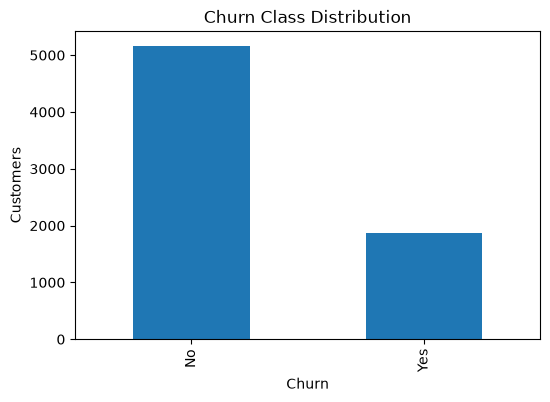

In [10]:
churn_percent = (df["Churn"].value_counts(normalize=True) * 100).round(2)
print(churn_percent)

plt.figure(figsize=(6, 4))
df["Churn"].value_counts().reindex(["No", "Yes"]).plot(kind="bar")
plt.title("Churn Class Distribution")
plt.xlabel("Churn")
plt.ylabel("Customers")
plt.show()

**Observation:** The classes are imbalanced: about **73.5%** of customers stayed and **26.5%** churned. This is why accuracy alone can be misleading.

### Numerical Features vs Churn

<Figure size 700x400 with 0 Axes>

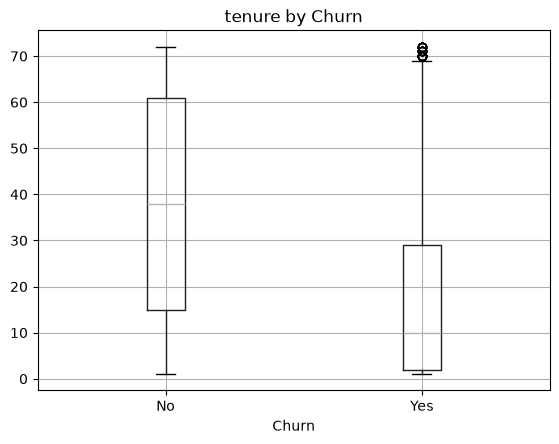

<Figure size 700x400 with 0 Axes>

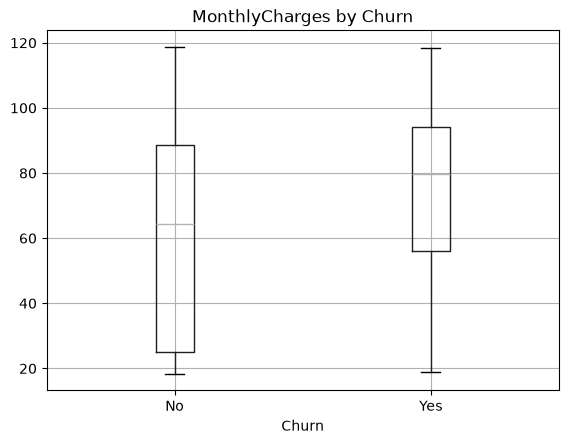

<Figure size 700x400 with 0 Axes>

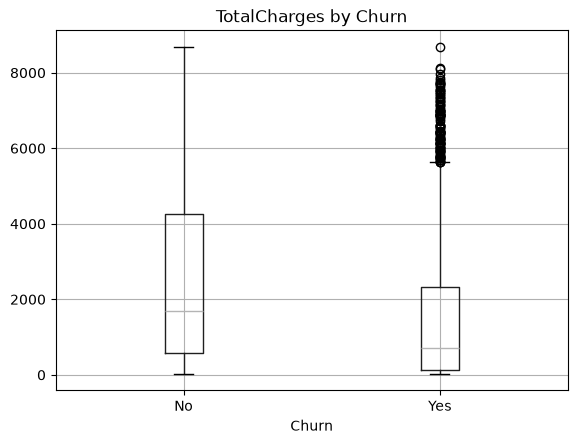

Median values by Churn:
       tenure  MonthlyCharges  TotalCharges
Churn                                      
No       38.0           64.45       1683.60
Yes      10.0           79.65        703.55


In [11]:
for column in ["tenure", "MonthlyCharges", "TotalCharges"]:
    plt.figure(figsize=(7, 4))
    df.boxplot(column=column, by="Churn")
    plt.suptitle("")
    plt.title(f"{column} by Churn")
    plt.show()

print("Median values by Churn:")
print(df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].median().round(2))

**Observation:** Customers who churned have much lower typical tenure and higher typical monthly charges. Their typical total charges are lower, which is consistent with many churned customers having shorter histories with the company. These are associations, not proof of causation.

### Contract vs Churn

Contract
Month-to-month    42.71
One year          11.28
Two year           2.85
Name: Churn, dtype: float64


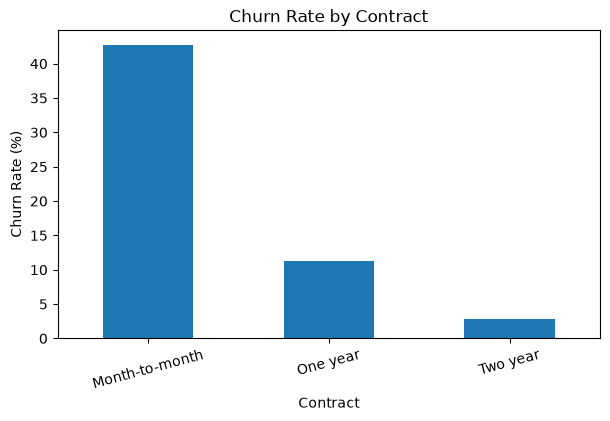

In [12]:
contract_churn = (
    df.groupby("Contract")["Churn"]
      .apply(lambda values: (values == "Yes").mean() * 100)
      .sort_values(ascending=False)
      .round(2)
)
print(contract_churn)

plt.figure(figsize=(7, 4))
contract_churn.plot(kind="bar")
plt.title("Churn Rate by Contract")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Contract")
plt.xticks(rotation=15)
plt.show()

**Observation:** Month-to-month customers show a much higher churn rate than customers on one-year or two-year contracts.

### Internet Service vs Churn

InternetService
Fiber optic    41.89
DSL            19.00
No              7.43
Name: Churn, dtype: float64


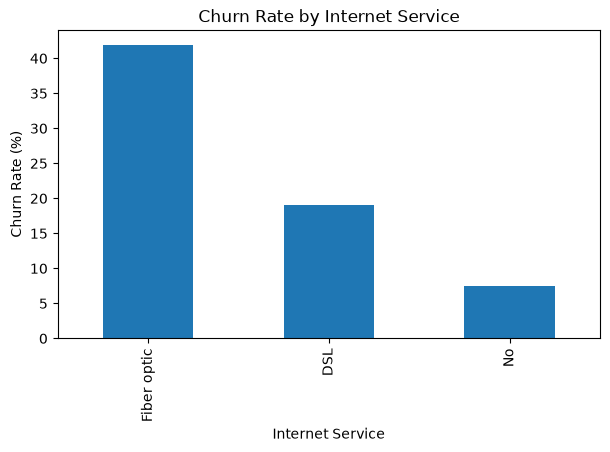

In [13]:
internet_churn = (
    df.groupby("InternetService")["Churn"]
      .apply(lambda values: (values == "Yes").mean() * 100)
      .sort_values(ascending=False)
      .round(2)
)
print(internet_churn)

plt.figure(figsize=(7, 4))
internet_churn.plot(kind="bar")
plt.title("Churn Rate by Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Internet Service")
plt.show()

**Observation:** Fiber-optic customers appear to have a higher churn rate than DSL customers or customers without internet service.

### Tech Support vs Churn

TechSupport
No                     41.65
Yes                    15.20
No internet service     7.43
Name: Churn, dtype: float64


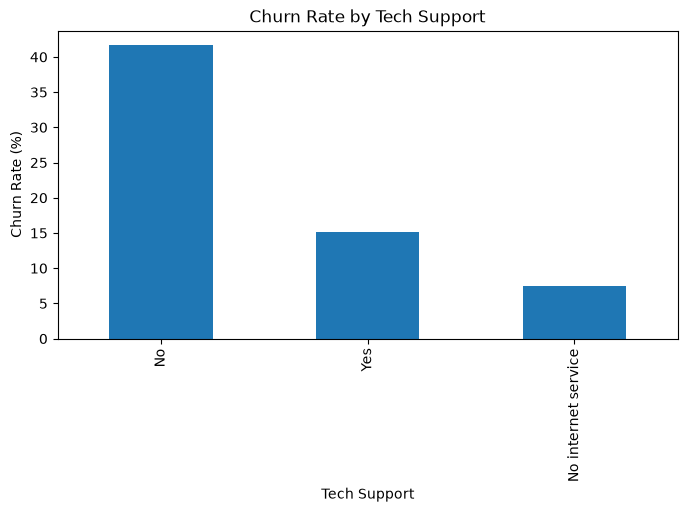

In [14]:
tech_churn = (
    df.groupby("TechSupport")["Churn"]
      .apply(lambda values: (values == "Yes").mean() * 100)
      .sort_values(ascending=False)
      .round(2)
)
print(tech_churn)

plt.figure(figsize=(8, 4))
tech_churn.plot(kind="bar")
plt.title("Churn Rate by Tech Support")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Tech Support")
plt.show()

**Observation:** Customers without tech support appear to have a higher churn rate than customers who have tech support. This relationship does not establish that tech support itself causes retention.

### Numeric Correlations

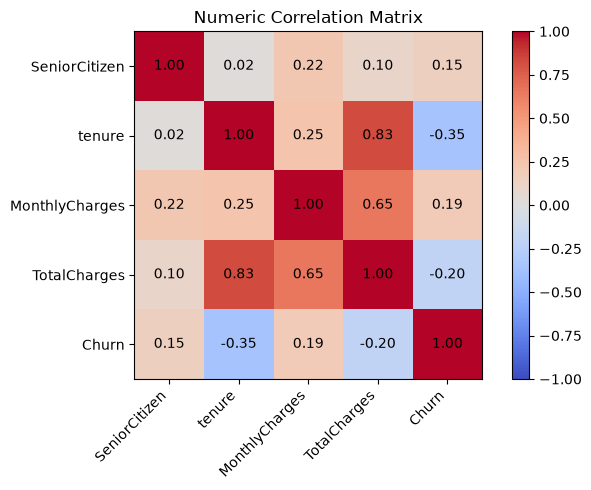

In [15]:
corr_data = df[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]].copy()
corr_data["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

corr_matrix = corr_data.corr()
plt.figure(figsize=(7, 5))
plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center")
plt.title("Numeric Correlation Matrix")
plt.tight_layout()
plt.show()

**Observation:** `tenure` has the strongest negative numeric correlation with churn in this small numeric subset. `TotalCharges` is strongly related to `tenure`, which is expected because total spending accumulates over time.

## 5. Features and Target

In [16]:
X = df.drop(columns="Churn")
y = df["Churn"].map({"No": 0, "Yes": 1})

print("X shape:", X.shape)
print("Target mapping: No = 0, Yes = 1")
print(y.value_counts().sort_index())

X shape: (7032, 19)
Target mapping: No = 0, Yes = 1
Churn
0    5163
1    1869
Name: count, dtype: int64


The target is encoded numerically so that `0` represents a customer who stayed and `1` represents a customer who churned.

## 6. Train / Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTraining target percentage:")
print((y_train.value_counts(normalize=True) * 100).round(2).sort_index())
print("\nTest target percentage:")
print((y_test.value_counts(normalize=True) * 100).round(2).sort_index())

Training shape: (5625, 19)
Test shape: (1407, 19)

Training target percentage:
Churn
0    73.42
1    26.58
Name: proportion, dtype: float64

Test target percentage:
Churn
0    73.42
1    26.58
Name: proportion, dtype: float64


The test set remains unseen during training so evaluation represents performance on new customers. `stratify=y` keeps a similar churn proportion in both sets.

## 7. Preprocessing Without Data Leakage

In [18]:
numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical features:", numerical_features)
print("\nCategorical features:", categorical_features)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


Categorical columns are one-hot encoded and numerical columns are standardized. The preprocessing is placed inside each Scikit-learn `Pipeline`. Therefore the encoder and scaler are **fit only on the training data**, then the learned transformations are applied to the test data. This prevents test information from leaking into training.

## 8. Baseline and Classification Models

In [19]:
models = {
    "Baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "k-NN": KNeighborsClassifier(n_neighbors=5)
}

trained_models = {}
results = []

for model_name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_score = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_score)
    })

    trained_models[model_name] = pipeline

/home/haitham/binx-ai-ml-internship/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


## 9. Model Comparison

In [20]:
results_df = pd.DataFrame(results).set_index("Model")
results_sorted = results_df.sort_values(["F1-score", "Recall"], ascending=False)
results_sorted.round(4)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Decision Tree,0.7896,0.6021,0.6150,0.6085,0.8296
Logistic Regression,0.8038,0.6485,0.5722,0.6080,0.8359
k-NN,0.7612,0.5480,0.5802,0.5636,0.7794
SVM,0.7918,0.6401,0.4947,0.5581,0.7886
Random Forest,0.7875,0.6307,0.4840,0.5477,0.8137
Baseline,0.7342,0.0000,0.0000,0.0000,0.5000


The baseline is important because a model should do more than simply predict the majority class. Here the baseline can achieve a seemingly reasonable accuracy by always predicting `No`, but its churn Recall and F1-score are zero. For churn detection, **Recall** matters because a false negative means missing a customer who actually leaves, while **F1-score** helps balance Recall with Precision.

In [21]:
best_model_name = results_sorted.index[0]
best_metrics = results_df.loc[best_model_name]

print("Selected model:", best_model_name)
print(best_metrics.round(4))

logistic_metrics = results_df.loc["Logistic Regression"]
print("\nLogistic Regression for comparison:")
print(logistic_metrics.round(4))

Selected model: Decision Tree
Accuracy     0.7896
Precision    0.6021
Recall       0.6150
F1-score     0.6085
ROC-AUC      0.8296
Name: Decision Tree, dtype: float64

Logistic Regression for comparison:
Accuracy     0.8038
Precision    0.6485
Recall       0.5722
F1-score     0.6080
ROC-AUC      0.8359
Name: Logistic Regression, dtype: float64


The selected model is determined from the executed results rather than hard-coded in advance. The highest F1-score is used as the primary rule, with Recall used as an additional churn-focused comparison. If another model has stronger Accuracy or ROC-AUC, that trade-off is still discussed rather than ignored.

## 10. Confusion Matrix for the Selected Model

Confusion matrix:
 [[881 152]
 [144 230]]


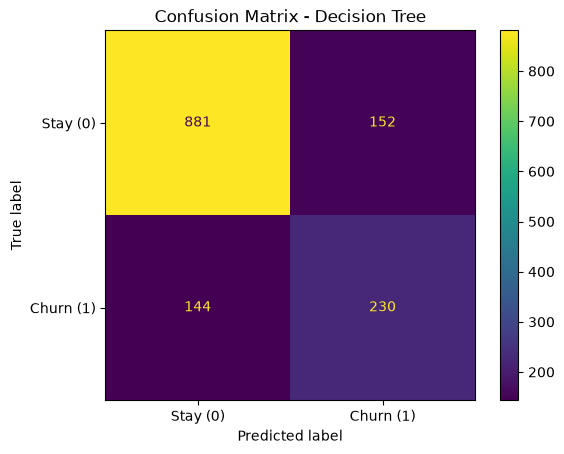

In [22]:
selected_model = trained_models[best_model_name]
y_pred_selected = selected_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_selected)
print("Confusion matrix:\n", cm)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stay (0)", "Churn (1)"]).plot()
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

- **TN:** correctly predicted a customer would stay.
- **FP:** predicted churn, but the customer actually stayed.
- **FN:** predicted stay, but the customer actually churned.
- **TP:** correctly predicted a customer would churn.

For this project, a **False Negative** is especially important because the company would fail to identify an at-risk customer who actually leaves.

## 11. Classification Report

In [23]:
print(classification_report(y_test, y_pred_selected, target_names=["Stay", "Churn"]))

              precision    recall  f1-score   support

        Stay       0.86      0.85      0.86      1033
       Churn       0.60      0.61      0.61       374

    accuracy                           0.79      1407
   macro avg       0.73      0.73      0.73      1407
weighted avg       0.79      0.79      0.79      1407



Precision answers: “When the model predicts churn, how often is it correct?” Recall answers: “Of the customers who actually churned, how many were detected?” F1-score combines both into one balance metric.

## 12. ROC Curves and ROC-AUC

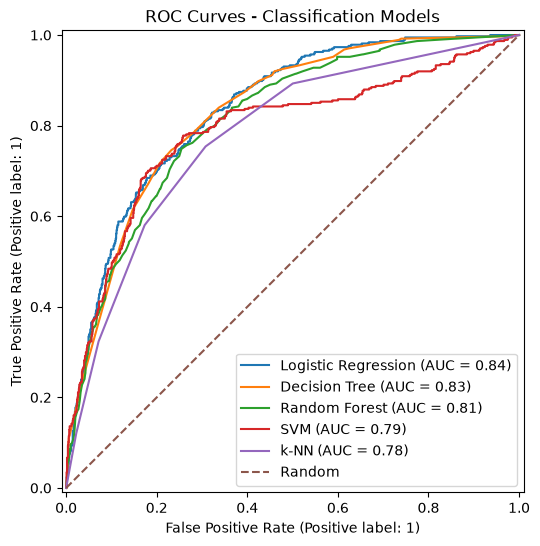

In [24]:
plt.figure(figsize=(8, 6))

for model_name, pipeline in trained_models.items():
    if model_name == "Baseline":
        continue
    y_score = pipeline.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_score, name=model_name, ax=plt.gca())

plt.plot([0, 1], [0, 1], "--", label="Random")
plt.title("ROC Curves - Classification Models")
plt.legend()
plt.show()

A ROC-AUC value closer to 1 indicates stronger separation between churn and non-churn customers across different classification thresholds.

## 13. Random Forest Feature Importance

,Importance
TotalCharges,0.1636
tenure,0.1411
MonthlyCharges,0.1345
Contract_Month-to-month,0.0510
PaymentMethod_Electronic check,0.0318
OnlineSecurity_No,0.0310
InternetService_Fiber optic,0.0305
TechSupport_No,0.0227
SeniorCitizen,0.0198
gender_Female,0.0185


<Figure size 800x500 with 0 Axes>

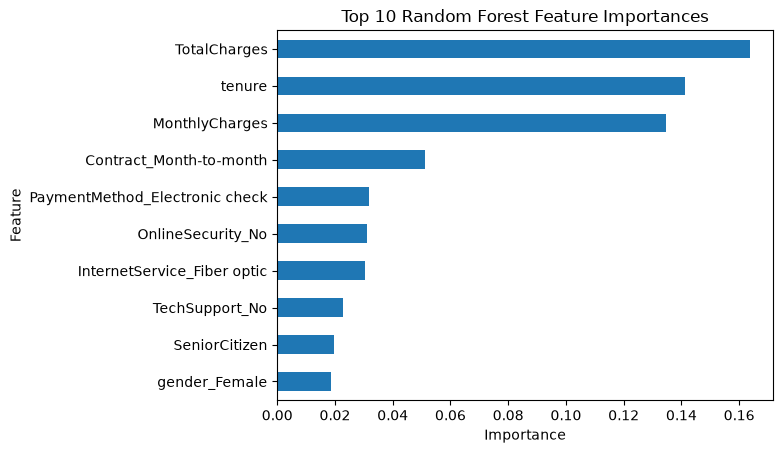

In [25]:
rf_pipeline = trained_models["Random Forest"]
rf_preprocessor = rf_pipeline.named_steps["preprocessor"]
rf_model = rf_pipeline.named_steps["model"]

feature_names = rf_preprocessor.get_feature_names_out()
feature_names = [name.replace("num__", "").replace("cat__", "") for name in feature_names]

feature_importance = (
    pd.Series(rf_model.feature_importances_, index=feature_names, name="Importance")
      .sort_values(ascending=False)
)

top_features = feature_importance.head(10).to_frame()
display(top_features.round(4))

plt.figure(figsize=(8, 5))
top_features.sort_values("Importance").plot(kind="barh", legend=False)
plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

Feature importance shows which transformed inputs helped the **Random Forest model** make its predictions. It does **not** prove that those variables cause churn. One-hot encoded categories are shown as separate features, such as a specific contract type or payment method.

## 14. Final Model Selection and Conclusion

In [26]:
baseline_metrics = results_df.loc["Baseline"]
selected = results_df.loc[best_model_name]
top_three_features = ", ".join(top_features.index[:3])

tn, fp, fn, tp = cm.ravel()

conclusion = f"""
### Final Conclusion

This project built an end-to-end binary classification workflow to predict telecom customer churn. The raw data required conversion of `TotalCharges` from text to numeric, removal of 11 rows with blank total charges, removal of the identifier `customerID`, categorical one-hot encoding, and numerical scaling. Preprocessing was kept inside Scikit-learn pipelines so the scaler and encoder learned only from the training set, preventing data leakage.

The models compared were Dummy Baseline, Logistic Regression, Decision Tree, Random Forest, SVM, and k-NN. The baseline reached **{baseline_metrics['Accuracy']:.4f} accuracy** but had **0 recall and 0 F1-score for churn**, showing why accuracy alone is not enough on an imbalanced target.

The selected model was **{best_model_name}** with **Accuracy = {selected['Accuracy']:.4f}**, **Precision = {selected['Precision']:.4f}**, **Recall = {selected['Recall']:.4f}**, **F1 = {selected['F1-score']:.4f}**, and **ROC-AUC = {selected['ROC-AUC']:.4f}**. Its confusion matrix contained **{tp} true positives** and **{fn} false negatives** for churn. The selection emphasizes F1 and Recall because missing a real churn customer is important in a retention setting.

The Random Forest interpretation ranked **{top_three_features}** among its strongest predictive inputs. These are model-based importance signals, not causal claims.

A limitation is that this project uses one historical dataset and beginner-level default model settings without hyperparameter tuning, resampling, or external validation. In practice, a telecom company could use this type of model to identify customers for retention review, but business actions and thresholds should be validated using future data and real intervention costs.
"""

display(Markdown(conclusion))


### Final Conclusion

This project built an end-to-end binary classification workflow to predict telecom customer churn. The raw data required conversion of `TotalCharges` from text to numeric, removal of 11 rows with blank total charges, removal of the identifier `customerID`, categorical one-hot encoding, and numerical scaling. Preprocessing was kept inside Scikit-learn pipelines so the scaler and encoder learned only from the training set, preventing data leakage.

The models compared were Dummy Baseline, Logistic Regression, Decision Tree, Random Forest, SVM, and k-NN. The baseline reached **0.7342 accuracy** but had **0 recall and 0 F1-score for churn**, showing why accuracy alone is not enough on an imbalanced target.

The selected model was **Decision Tree** with **Accuracy = 0.7896**, **Precision = 0.6021**, **Recall = 0.6150**, **F1 = 0.6085**, and **ROC-AUC = 0.8296**. Its confusion matrix contained **230 true positives** and **144 false negatives** for churn. The selection emphasizes F1 and Recall because missing a real churn customer is important in a retention setting.

The Random Forest interpretation ranked **TotalCharges, tenure, MonthlyCharges** among its strongest predictive inputs. These are model-based importance signals, not causal claims.

A limitation is that this project uses one historical dataset and beginner-level default model settings without hyperparameter tuning, resampling, or external validation. In practice, a telecom company could use this type of model to identify customers for retention review, but business actions and thresholds should be validated using future data and real intervention costs.
